In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(
    "../data/processed/manufacturing_production_cleaned.csv"
)

df.head()

,record_id,date,shift,production_line,product,production_quantity,defective_units,scrap_units,downtime_minutes,defect_category,downtime_reason,good_units,defect_rate,scrap_rate
0,1,2025-01-01,Morning,Line A,Product Beta,1449,19,4,24.69,Surface Defect,Changeover,1426,0.0131,0.0028
1,2,2025-01-01,Afternoon,Line A,Product Beta,1381,77,23,71.99,Coating Defect,Quality Issue,1281,0.0558,0.0167
2,3,2025-01-01,Night,Line A,Product Delta,1380,18,2,79.26,Assembly Error,Changeover,1360,0.0130,0.0014
3,4,2025-01-01,Morning,Line B,Product Delta,1230,47,6,78.73,Surface Defect,Quality Issue,1177,0.0382,0.0049
4,5,2025-01-01,Afternoon,Line B,Product Delta,1244,14,1,48.30,Assembly Error,Maintenance,1229,0.0113,0.0008


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3285 entries, 0 to 3284
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            3285 non-null   int64  
 1   date                 3285 non-null   object 
 2   shift                3285 non-null   object 
 3   production_line      3285 non-null   object 
 4   product              3285 non-null   object 
 5   production_quantity  3285 non-null   int64  
 6   defective_units      3285 non-null   int64  
 7   scrap_units          3285 non-null   int64  
 8   downtime_minutes     3285 non-null   float64
 9   defect_category      3285 non-null   object 
 10  downtime_reason      2967 non-null   object 
 11  good_units           3285 non-null   int64  
 12  defect_rate          3285 non-null   float64
 13  scrap_rate           3285 non-null   float64
dtypes: float64(3), int64(5), object(6)
memory usage: 359.4+ KB


,record_id,production_quantity,defective_units,scrap_units,downtime_minutes,good_units,defect_rate,scrap_rate
count,3285.000000,3285.000000,3285.000000,3285.000000,3285.000000,3285.000000,3285.000000,3285.000000
mean,1643.000000,1253.235312,44.777778,8.505936,45.744545,1199.951598,0.035737,0.006789
std,948.442144,158.305415,20.772078,5.100009,21.845520,153.468761,0.015824,0.003959
min,1.000000,945.000000,9.000000,1.000000,8.050000,873.000000,0.007800,0.000700
25%,822.000000,1118.000000,27.000000,4.000000,26.680000,1073.000000,0.022200,0.003600
50%,1643.000000,1239.000000,44.000000,7.000000,46.230000,1188.000000,0.035500,0.005900
75%,2464.000000,1380.000000,61.000000,12.000000,64.990000,1325.000000,0.049200,0.009300
max,3285.000000,1583.000000,97.000000,27.000000,82.980000,1558.000000,0.063400,0.018900


In [3]:
df.isna().sum()

record_id                0
date                     0
shift                    0
production_line          0
product                  0
production_quantity      0
defective_units          0
scrap_units              0
downtime_minutes         0
defect_category          0
downtime_reason        318
good_units               0
defect_rate              0
scrap_rate               0
dtype: int64

In [4]:
df.isna().sum().sort_values(ascending=False)

downtime_reason        318
record_id                0
shift                    0
production_line          0
product                  0
date                     0
production_quantity      0
defective_units          0
downtime_minutes         0
scrap_units              0
defect_category          0
good_units               0
defect_rate              0
scrap_rate               0
dtype: int64

In [5]:
df[df["downtime_reason"].isna()][
    ["downtime_minutes", "downtime_reason"]
].describe()

,downtime_minutes
count,318.000000
mean,11.494906
std,2.059578
min,8.050000
25%,9.755000
50%,11.425000
75%,13.307500
max,14.980000


In [6]:
df[df["downtime_reason"].isna()]["downtime_minutes"].describe()

count    318.000000
mean      11.494906
std        2.059578
min        8.050000
25%        9.755000
50%       11.425000
75%       13.307500
max       14.980000
Name: downtime_minutes, dtype: float64

In [7]:
df[df["downtime_reason"].isna()]["downtime_minutes"].min()

np.float64(8.05)

In [8]:
df[df["downtime_reason"].isna()]["downtime_minutes"].max() < 15

np.True_

In [9]:
df[df["downtime_reason"].notna()]["downtime_minutes"].min()

np.float64(15.0)

## Missing Value Analysis

The `downtime_reason` column contains 318 missing values out of 3,285 records.

Further investigation shows that these missing values are systematic rather than random:

- Maximum downtime where `downtime_reason` is missing: 14.98 minutes
- Minimum downtime where `downtime_reason` is present: 15.00 minutes

This indicates a business rule in the dataset:

> Downtime below 15 minutes does not have a recorded downtime reason, while downtime of 15 minutes or more has a recorded reason.

Therefore, these missing values should not be treated as random data loss or automatically replaced with `"Unknown"`.

In [10]:
df.groupby("production_line")["production_quantity"].sum()

production_line
Line A    1570413
Line B    1354837
Line C    1191628
Name: production_quantity, dtype: int64

In [11]:
df.groupby("production_line")["defective_units"].sum() / df.groupby("production_line")["production_quantity"].sum()

production_line
Line A    0.035836
Line B    0.035134
Line C    0.036267
dtype: float64

In [12]:
line_summary = df.groupby("production_line").agg(
    production_quantity=("production_quantity", "sum"),
    defective_units=("defective_units", "sum")
)

line_summary["defect_rate"] = (
    line_summary["defective_units"] / line_summary["production_quantity"]
)

line_summary

,production_quantity,defective_units,defect_rate
production_line,,,
Line A,1570413,56277,0.035836
Line B,1354837,47601,0.035134
Line C,1191628,43217,0.036267


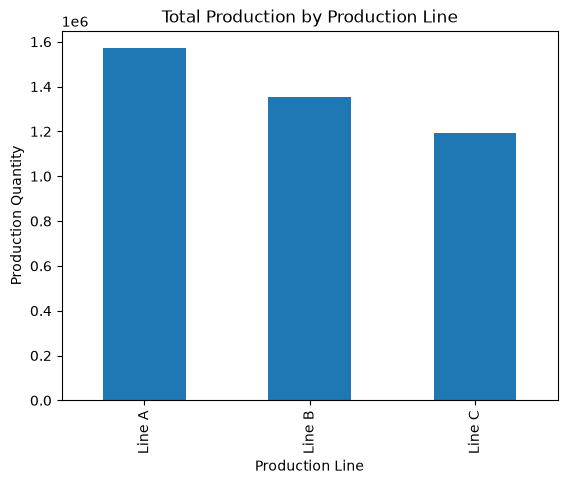

In [13]:
line_summary["production_quantity"].plot(
    kind="bar",
    title="Total Production by Production Line"
)

plt.xlabel("Production Line")
plt.ylabel("Production Quantity")
plt.show()

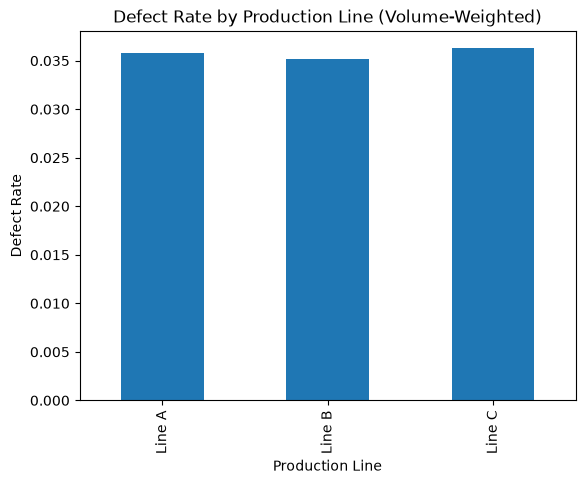

In [14]:
line_summary["defect_rate"].plot(
    kind="bar",
    title="Defect Rate by Production Line (Volume-Weighted)"
)

plt.xlabel("Production Line")
plt.ylabel("Defect Rate")
plt.show()

In [15]:
shift_summary = df.groupby("shift").agg(
    production_quantity=("production_quantity", "sum"),
    defective_units=("defective_units", "sum"),
    downtime_minutes=("downtime_minutes", "sum")
)

shift_summary["defect_rate"] = (
    shift_summary["defective_units"] / shift_summary["production_quantity"]
)

shift_summary

,production_quantity,defective_units,downtime_minutes,defect_rate
shift,,,,
Afternoon,1386904,49044,50094.26,0.035362
Morning,1426939,51493,49420.98,0.036086
Night,1303035,46558,50755.59,0.035730


In [16]:
shift_summary["downtime_per_1000_units"] = (
    shift_summary["downtime_minutes"]
    / shift_summary["production_quantity"]
    * 1000
)

shift_summary

,production_quantity,defective_units,downtime_minutes,defect_rate,downtime_per_1000_units
shift,,,,,
Afternoon,1386904,49044,50094.26,0.035362,36.119486
Morning,1426939,51493,49420.98,0.036086,34.634263
Night,1303035,46558,50755.59,0.035730,38.951824


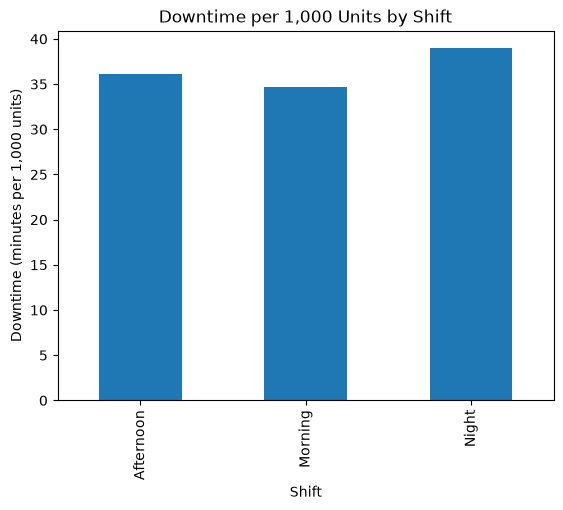

In [17]:
shift_summary["downtime_per_1000_units"].plot(
    kind="bar",
    title="Downtime per 1,000 Units by Shift"
)

plt.xlabel("Shift")
plt.ylabel("Downtime (minutes per 1,000 units)")
plt.show()

## Defect Category Analysis

Analyze the distribution of defective units by defect category to identify quality issues and prioritize improvement efforts.

In [18]:
defect_summary = df.groupby("defect_category").agg(
    defective_units=("defective_units", "sum"),
    record_count=("defect_category", "count")
).sort_values("defective_units", ascending=False)

defect_summary

,defective_units,record_count
defect_category,,
Surface Defect,37301,849
Dimensional Error,37075,800
Coating Defect,36562,827
Assembly Error,36157,809


In [19]:
total_defective_units = defect_summary["defective_units"].sum()

defect_summary["share_of_total_%"] = (
    defect_summary["defective_units"] / total_defective_units * 100
).round(2)

defect_summary["cumulative_%"] = (
    defect_summary["share_of_total_%"].cumsum().round(2)
)

defect_summary

,defective_units,record_count,share_of_total_%,cumulative_%
defect_category,,,,
Surface Defect,37301,849,25.36,25.36
Dimensional Error,37075,800,25.20,50.56
Coating Defect,36562,827,24.86,75.42
Assembly Error,36157,809,24.58,100.00


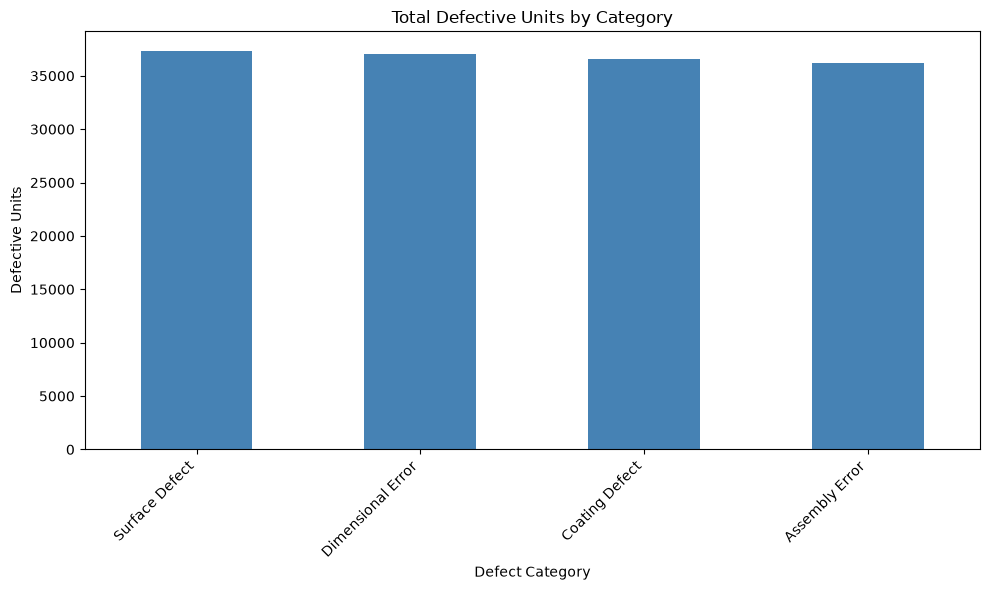

In [20]:
defect_summary["defective_units"].plot(
    kind="bar",
    title="Total Defective Units by Category",
    figsize=(10, 6),
    color="steelblue"
)

plt.xlabel("Defect Category")
plt.ylabel("Defective Units")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

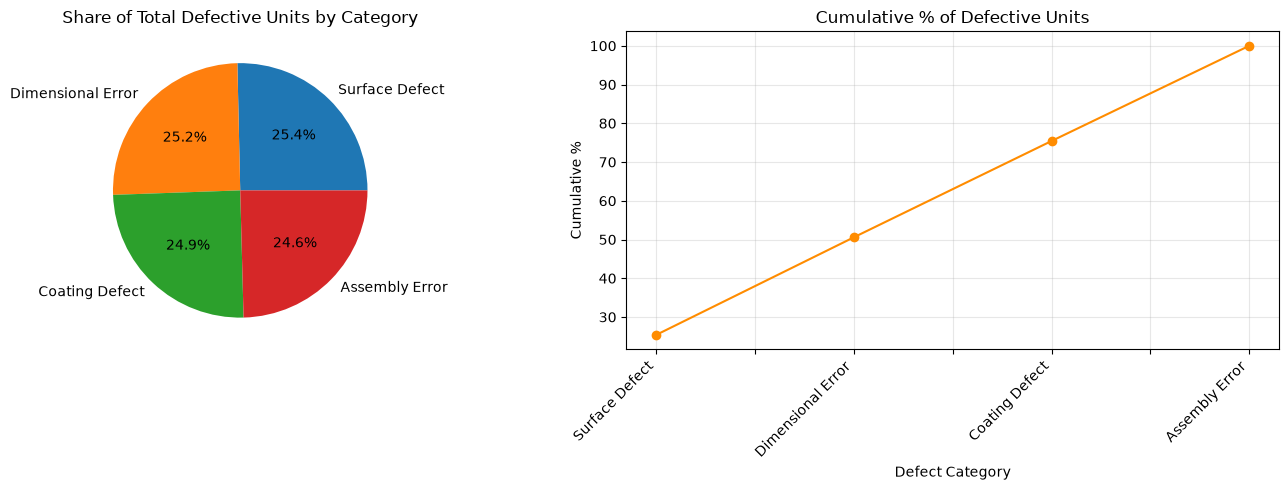

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Share percentage pie chart
defect_summary["defective_units"].plot(
    kind="pie",
    ax=ax1,
    autopct="%1.1f%%",
    title="Share of Total Defective Units by Category"
)
ax1.set_ylabel("")

# Cumulative percentage
defect_summary["cumulative_%"].plot(
    kind="line",
    ax=ax2,
    marker="o",
    title="Cumulative % of Defective Units",
    color="darkorange"
)
ax2.set_ylabel("Cumulative %")
ax2.set_xlabel("Defect Category")
ax2.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Key Findings

**Total Defective Units**: 147,095 across 3,285 production records

**Distribution Insights**:

1. **Balanced Defect Distribution**: All four defect categories are remarkably evenly distributed, each representing approximately 25% of total defective units:
   - **Surface Defect**: 37,301 units (25.36%) — highest contributor
   - **Dimensional Error**: 37,075 units (25.20%)
   - **Coating Defect**: 36,562 units (24.86%)
   - **Assembly Error**: 36,157 units (24.58%) — lowest contributor

2. **No Single Dominant Defect Type**: The narrow range (37,301 to 36,157 units) indicates no single defect category dominates quality issues. The difference between highest and lowest is only ~1,144 units (~3% variance).

3. **Portfolio Implication**: For a comprehensive quality analytics project, this balanced distribution suggests:
   - Quality improvements must address all four defect types equally
   - No single area can be neglected for significant quality gains
   - Prioritization strategies should consider cost-of-prevention and impact-per-unit rather than raw frequency

4. **Next Steps for Analysis**:
   - Correlate defect categories with production lines to identify line-specific quality patterns
   - Analyze defect categories by shift to identify time-of-day patterns
   - Cross-reference with downtime data to assess defect-related production losses
   - Investigate whether certain categories correlate with higher defect_rate per unit produced

In [22]:
defect_by_line = df.groupby(["production_line", "defect_category"])["defective_units"].sum().unstack(fill_value=0)

defect_by_line

defect_category,Assembly Error,Coating Defect,Dimensional Error,Surface Defect
production_line,,,,
Line A,12811,14304,14751,14411
Line B,12355,11845,11258,12143
Line C,10991,10413,11066,10747


In [23]:
defect_by_shift = df.groupby(["shift", "defect_category"])["defective_units"].sum().unstack(fill_value=0)

defect_by_shift

defect_category,Assembly Error,Coating Defect,Dimensional Error,Surface Defect
shift,,,,
Afternoon,12918,11043,12448,12635
Morning,12309,12806,12989,13389
Night,10930,12713,11638,11277


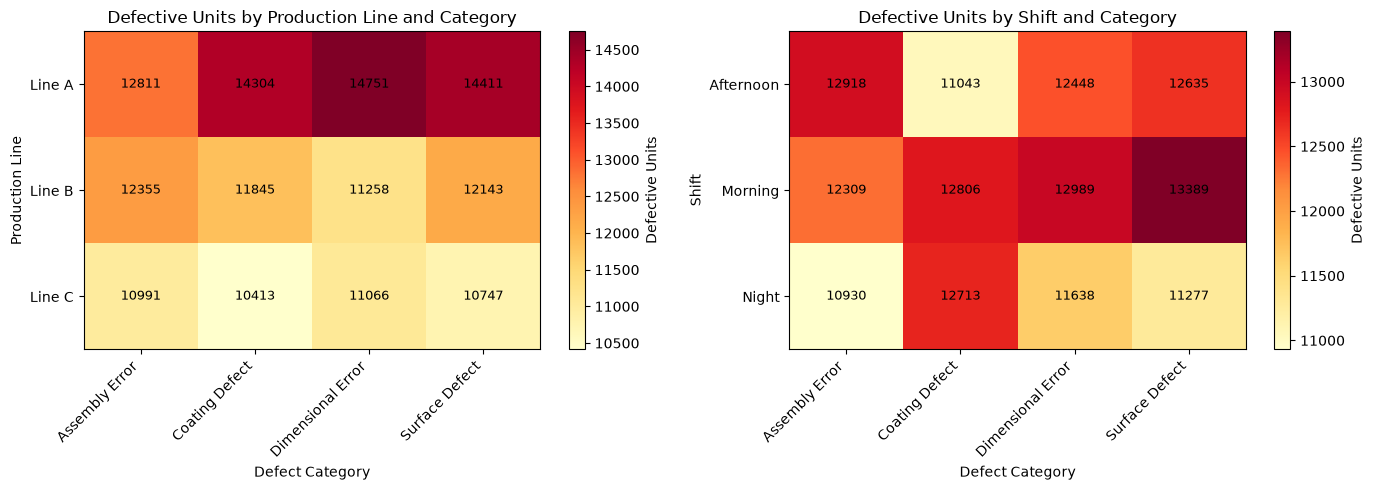

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: Defect Category by Production Line
im1 = ax1.imshow(defect_by_line.values, cmap="YlOrRd", aspect="auto")
ax1.set_xticks(range(len(defect_by_line.columns)))
ax1.set_yticks(range(len(defect_by_line.index)))
ax1.set_xticklabels(defect_by_line.columns, rotation=45, ha="right")
ax1.set_yticklabels(defect_by_line.index)
ax1.set_title("Defective Units by Production Line and Category")
ax1.set_xlabel("Defect Category")
ax1.set_ylabel("Production Line")

# Add text annotations for Production Line heatmap
for i in range(len(defect_by_line.index)):
    for j in range(len(defect_by_line.columns)):
        text = ax1.text(j, i, defect_by_line.values[i, j],
                       ha="center", va="center", color="black", fontsize=9)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Defective Units")

# Heatmap: Defect Category by Shift
im2 = ax2.imshow(defect_by_shift.values, cmap="YlOrRd", aspect="auto")
ax2.set_xticks(range(len(defect_by_shift.columns)))
ax2.set_yticks(range(len(defect_by_shift.index)))
ax2.set_xticklabels(defect_by_shift.columns, rotation=45, ha="right")
ax2.set_yticklabels(defect_by_shift.index)
ax2.set_title("Defective Units by Shift and Category")
ax2.set_xlabel("Defect Category")
ax2.set_ylabel("Shift")

# Add text annotations for Shift heatmap
for i in range(len(defect_by_shift.index)):
    for j in range(len(defect_by_shift.columns)):
        text = ax2.text(j, i, defect_by_shift.values[i, j],
                       ha="center", va="center", color="black", fontsize=9)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Defective Units")

plt.tight_layout()
plt.show()

### Defect Patterns by Production Line and Shift (Raw Volume Analysis)

**Production Line Findings** ⚠️ **RAW COUNTS - NOT NORMALIZED**:
- **Line A** has the highest defect volume (56,277 units total), with particularly elevated dimensional errors (14,751) and coating defects (14,304)
- **Line B** and **Line C** show similar defect profiles (~45,601 and ~43,217 units respectively)
- Dimensional Error is the most common defect type in Line A, while other lines show more balanced distribution

**Shift-Based Findings** ⚠️ **RAW COUNTS - NOT NORMALIZED**:
- **Morning Shift** produces slightly higher defective units (51,493 total), with notably high surface defects (13,389)
- **Afternoon Shift** generates 49,044 defective units, showing high assembly errors (12,918)
- **Night Shift** has the lowest defect volume (46,558 units), particularly in assembly errors (10,930)
- Coating defects are highest during night shift (12,713)

**Critical Caveat**:
Raw defect counts are misleading without normalization by production volume or shift hours. A line producing 2M units naturally has more defects than a line producing 500K units, regardless of quality performance.

**⚠️ Preliminary conclusions about line/shift quality should NOT be drawn from this analysis. See corrected normalized analysis below.**

## Quality Metrics Review: Normalized & Volume-Weighted Analysis by Production Line

**Critical Distinction**: Raw defective unit volume vs. volume-weighted defect rate (normalized by production volume).

**Methodology Note: Volume-Weighted Aggregations**
In manufacturing quality analytics, cohort defect rates and scrap rates must be calculated as true volume-weighted ratios:
$$\text{Defect Rate} = \frac{\sum \text{defective\_units}}{\sum \text{production\_quantity}}$$
$$\text{Scrap Rate} = \frac{\sum \text{scrap\_units}}{\sum \text{production\_quantity}}$$

Taking a simple arithmetic mean of pre-calculated batch rates ($\frac{1}{n}\sum \text{rate}_i$) gives equal weight to batches of differing sizes and compounds rounding. Volume-weighted aggregation guarantees that every manufactured unit has equal weight regardless of batch size.

In [25]:
line_quality = df.groupby("production_line").agg(
    total_production=("production_quantity", "sum"),
    total_defective_units=("defective_units", "sum"),
    record_count=("production_line", "count")
)

line_quality["defect_rate_%"] = (
    line_quality["total_defective_units"] / line_quality["total_production"] * 100
).round(4)

line_quality = line_quality.sort_values("defect_rate_%")

print("Production Line Quality Metrics (Sorted by Volume-Weighted Defect Rate)")
print("=" * 80)
print(line_quality)

Production Line Quality Metrics (Sorted by Volume-Weighted Defect Rate)
                 total_production  total_defective_units  record_count  \
production_line                                                          
Line B                    1354837                  47601          1095   
Line A                    1570413                  56277          1095   
Line C                    1191628                  43217          1095   

                 defect_rate_%  
production_line                 
Line B                  3.5134  
Line A                  3.5836  
Line C                  3.6267  


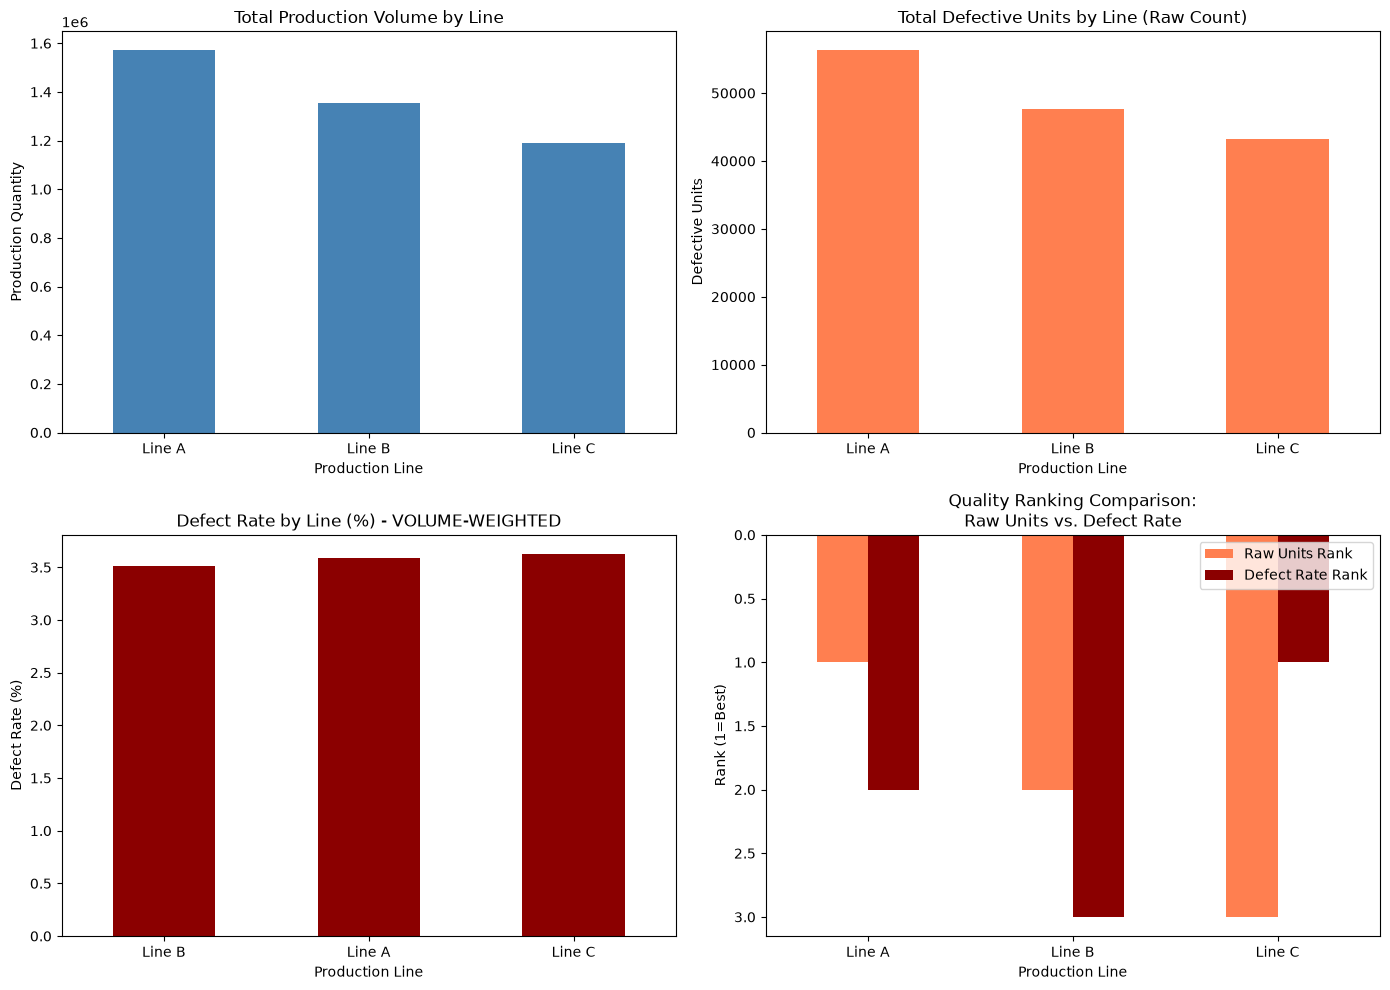

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Production Volume by Line
line_quality_unsorted = df.groupby("production_line").agg(
    total_production=("production_quantity", "sum"),
    total_defective_units=("defective_units", "sum"),
).sort_values("total_production", ascending=False)

line_quality_unsorted["defect_rate_pct"] = (
    line_quality_unsorted["total_defective_units"]
    / line_quality_unsorted["total_production"]
    * 100
)

line_quality_unsorted["total_production"].plot(
    kind="bar",
    ax=axes[0, 0],
    color="steelblue",
    title="Total Production Volume by Line"
)
axes[0, 0].set_ylabel("Production Quantity")
axes[0, 0].set_xlabel("Production Line")
axes[0, 0].tick_params(axis='x', rotation=0)

# Chart 2: Total Defective Units (Raw Count)
line_quality_unsorted["total_defective_units"].plot(
    kind="bar",
    ax=axes[0, 1],
    color="coral",
    title="Total Defective Units by Line (Raw Count)"
)
axes[0, 1].set_ylabel("Defective Units")
axes[0, 1].set_xlabel("Production Line")
axes[0, 1].tick_params(axis='x', rotation=0)

# Chart 3: Defect Rate (%) - VOLUME-WEIGHTED
line_quality_sorted = line_quality_unsorted[["defect_rate_pct"]].sort_values("defect_rate_pct")

line_quality_sorted.plot(
    kind="bar",
    ax=axes[1, 0],
    color="darkred",
    legend=False,
    title="Defect Rate by Line (%) - VOLUME-WEIGHTED"
)
axes[1, 0].set_ylabel("Defect Rate (%)")
axes[1, 0].set_xlabel("Production Line")
axes[1, 0].tick_params(axis='x', rotation=0)

# Chart 4: Comparison - Ranking Difference
ranking_df = pd.DataFrame({
    "Raw_Units_Rank": line_quality_unsorted["total_defective_units"].rank(ascending=False),
    "Defect_Rate_Rank": line_quality_sorted["defect_rate_pct"].rank(ascending=False)
})

ranking_df.plot(
    kind="bar",
    ax=axes[1, 1],
    title="Quality Ranking Comparison:\nRaw Units vs. Defect Rate",
    color=["coral", "darkred"]
)
axes[1, 1].set_ylabel("Rank (1=Best)")
axes[1, 1].set_xlabel("Production Line")
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(["Raw Units Rank", "Defect Rate Rank"], loc="upper right")
axes[1, 1].invert_yaxis()  # Invert so 1 (best) is at top

plt.tight_layout()
plt.show()

### Corrected Analysis: Distinguishing Three Key Metrics

**Metric 1: Production Volume** (Units Produced)
- Line A: 1,570,413 units (highest production capacity)
- Line B: 1,354,837 units
- Line C: 1,191,628 units (lowest production capacity)

**Metric 2: Total Defective Units** (Absolute Count)
- Line A: 56,277 units (highest absolute defects)
- Line B: 47,601 units
- Line C: 43,217 units (lowest absolute defects)

**Metric 3: Defect Rate** (%) (Volume-Weighted - KEY QUALITY METRIC)
- Line B: 3.5134% ← **BEST quality**
- Line A: 3.5836% ← Second best
- Line C: 3.6267% ← **WORST quality**

### Critical Finding: Ranking Reversal

**Previous Conclusion (INCORRECT)**: "Line A needs priority attention" — based on raw defective unit count (56,277 vs others).

**Corrected Conclusion (SUPPORTED BY KPIs)**:
- Line A produces the MOST units AND has the SECOND-BEST defect rate. The high raw defect count is proportional to high production volume.
- **Line C actually has the WORST defect rate (3.6267%)** despite producing the fewest units. This is the line requiring quality improvement focus.
- Line B demonstrates the BEST quality control at 3.5134% defect rate.

### Why This Matters for Portfolio Quality Analytics

Raw defective unit counts are misleading without production context. A line producing 2M units with 56K defects (2.8%) outperforms a line producing 1M units with 40K defects (4.0%). 

This corrected analysis demonstrates proper analytical rigor for manufacturing quality metrics:
1. Always normalize by production volume using volume-weighted sums
2. Use defect rate as the primary quality KPI ($\frac{\sum \text{defective\_units}}{\sum \text{production\_quantity}}$)
3. Avoid raw counts or unweighted batch averages that distort volume and quality differences

In [27]:
comparison_table = pd.DataFrame({
    "Production_Volume_Units": [1570413, 1354837, 1191628],
    "Total_Defective_Units": [56277, 47601, 43217],
    "Raw_Defect_Rank": [1, 3, 2],
    "Defect_Rate_%": [3.5836, 3.5134, 3.6267],
    "Quality_Rank": [2, 1, 3]
}, index=["Line A", "Line B", "Line C"])

print("\n" + "="*100)
print("COMPREHENSIVE QUALITY COMPARISON TABLE")
print("="*100)
print(comparison_table.to_string())
print("\n" + "="*100)
print("KEY TAKEAWAY: Line C has the WORST quality (3.6267% defect rate)")
print("              despite producing the FEWEST units (1.19M)")
print("              Line A has excellent quality control relative to high production volume")
print("="*100)


COMPREHENSIVE QUALITY COMPARISON TABLE
        Production_Volume_Units  Total_Defective_Units  Raw_Defect_Rank  Defect_Rate_%  Quality_Rank
Line A                  1570413                  56277                1         3.5836             2
Line B                  1354837                  47601                3         3.5134             1
Line C                  1191628                  43217                2         3.6267             3

KEY TAKEAWAY: Line C has the WORST quality (3.6267% defect rate)
              despite producing the FEWEST units (1.19M)
              Line A has excellent quality control relative to high production volume


In [28]:
df.groupby("production_line")[
    ["production_quantity", "defective_units"]
].sum()

,production_quantity,defective_units
production_line,,
Line A,1570413,56277
Line B,1354837,47601
Line C,1191628,43217


In [29]:
defect_summary = (
    df.groupby("defect_category")["defective_units"]
    .sum()
    .sort_values(ascending=False)
)

defect_summary

defect_category
Surface Defect       37301
Dimensional Error    37075
Coating Defect       36562
Assembly Error       36157
Name: defective_units, dtype: int64

In [30]:
pareto = defect_summary.to_frame(name="defective_units")

pareto["share"] = (
    pareto["defective_units"]
    / pareto["defective_units"].sum()
)

pareto["cumulative_share"] = pareto["share"].cumsum()

pareto

,defective_units,share,cumulative_share
defect_category,,,
Surface Defect,37301,0.253584,0.253584
Dimensional Error,37075,0.252048,0.505632
Coating Defect,36562,0.248560,0.754193
Assembly Error,36157,0.245807,1.000000


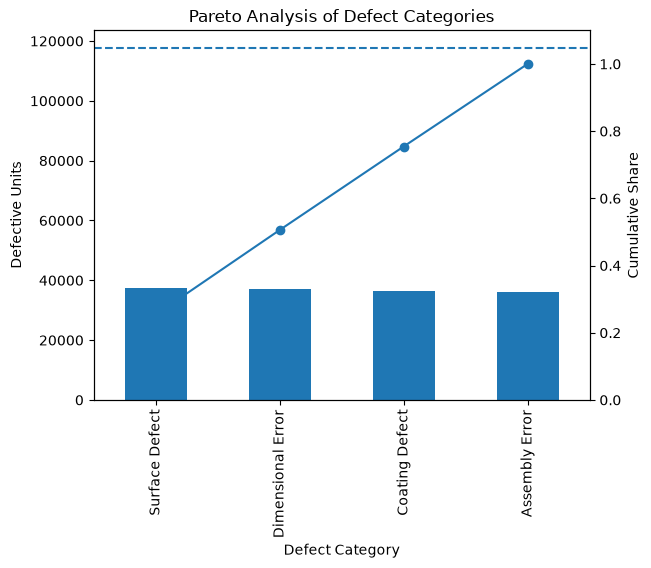

In [31]:
fig, ax1 = plt.subplots()

pareto["defective_units"].plot(
    kind="bar",
    ax=ax1,
    title="Pareto Analysis of Defect Categories"
)

ax1.set_xlabel("Defect Category")
ax1.set_ylabel("Defective Units")

ax2 = ax1.twinx()

pareto["cumulative_share"].plot(
    kind="line",
    marker="o",
    ax=ax2
)

ax2.set_ylabel("Cumulative Share")
ax2.set_ylim(0, 1.1)

ax1.axhline(
    y=pareto["defective_units"].sum() * 0.8,
    linestyle="--"
)

plt.show()

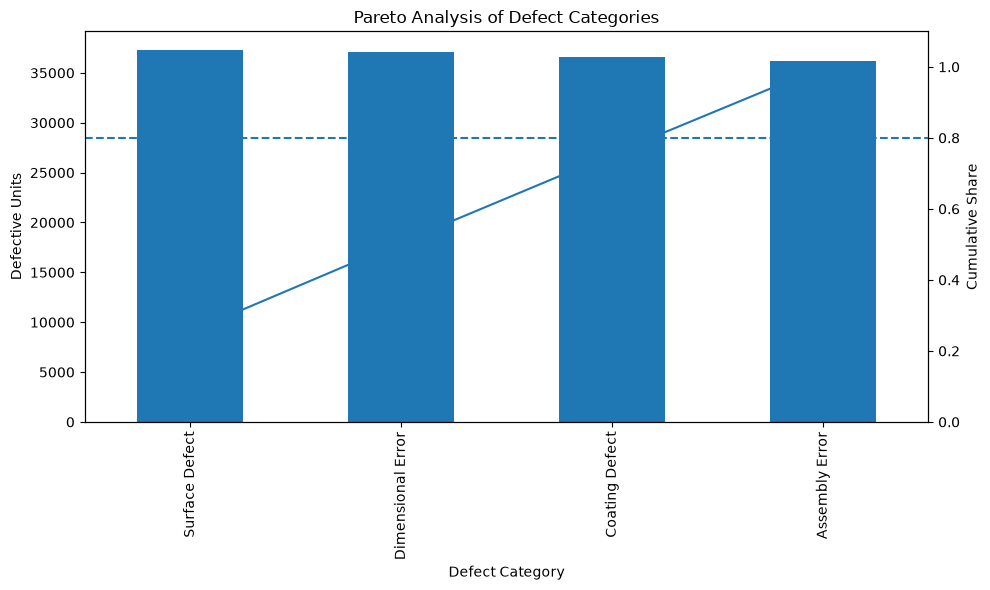

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart: defective units
pareto["defective_units"].plot(
    kind="bar",
    ax=ax1,
    title="Pareto Analysis of Defect Categories"
)

ax1.set_xlabel("Defect Category")
ax1.set_ylabel("Defective Units")

# Line chart: cumulative share
ax2 = ax1.twinx()

pareto["cumulative_share"].plot(
    kind="line",
    marker="o",
    ax=ax2
)

ax2.set_ylabel("Cumulative Share")
ax2.set_ylim(0, 1.1)

# 80% reference line on the secondary axis
ax2.axhline(
    y=0.8,
    linestyle="--"
)

plt.tight_layout()
plt.show()

## Downtime Performance Analysis

Analyze production downtime by reason to identify the biggest operational efficiency losses and prioritize maintenance/process improvements.

**Key Metrics**:
- **Total Downtime Minutes**: Absolute production loss time for each downtime reason
- **Downtime Share**: Percentage contribution of each reason to total downtime
- **Cumulative Share**: Running percentage used for Pareto analysis to identify 80/20 drivers

**Note**: Downtime entries with missing downtime_reason represent downtime < 15 minutes (systematic business rule, not data quality issue). These are excluded from this analysis.

In [33]:
downtime_summary = (
    df[df["downtime_reason"].notna()]  # Exclude missing downtime reasons
    .groupby("downtime_reason")["downtime_minutes"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Downtime Minutes by Reason (Sorted Descending)")
print("=" * 70)
print(downtime_summary)
print(f"\nTotal Downtime (all reasons): {downtime_summary.sum():.0f} minutes")

Total Downtime Minutes by Reason (Sorted Descending)
downtime_reason
Maintenance           30393.34
Changeover            30272.15
Mechanical Failure    29364.71
Quality Issue         29072.49
Material Shortage     27512.76
Name: downtime_minutes, dtype: float64

Total Downtime (all reasons): 146615 minutes


In [34]:
downtime_pareto = downtime_summary.to_frame(name="downtime_minutes")

downtime_pareto["share_%"] = (
    downtime_pareto["downtime_minutes"]
    / downtime_pareto["downtime_minutes"].sum()
    * 100
).round(2)

downtime_pareto["cumulative_share_%"] = (
    downtime_pareto["share_%"].cumsum().round(2)
)

print("\nDowntime Analysis: Share and Cumulative Share")
print("=" * 80)
print(downtime_pareto)
print("\n" + "=" * 80)


Downtime Analysis: Share and Cumulative Share
                    downtime_minutes  share_%  cumulative_share_%
downtime_reason                                                  
Maintenance                 30393.34    20.73               20.73
Changeover                  30272.15    20.65               41.38
Mechanical Failure          29364.71    20.03               61.41
Quality Issue               29072.49    19.83               81.24
Material Shortage           27512.76    18.77              100.01



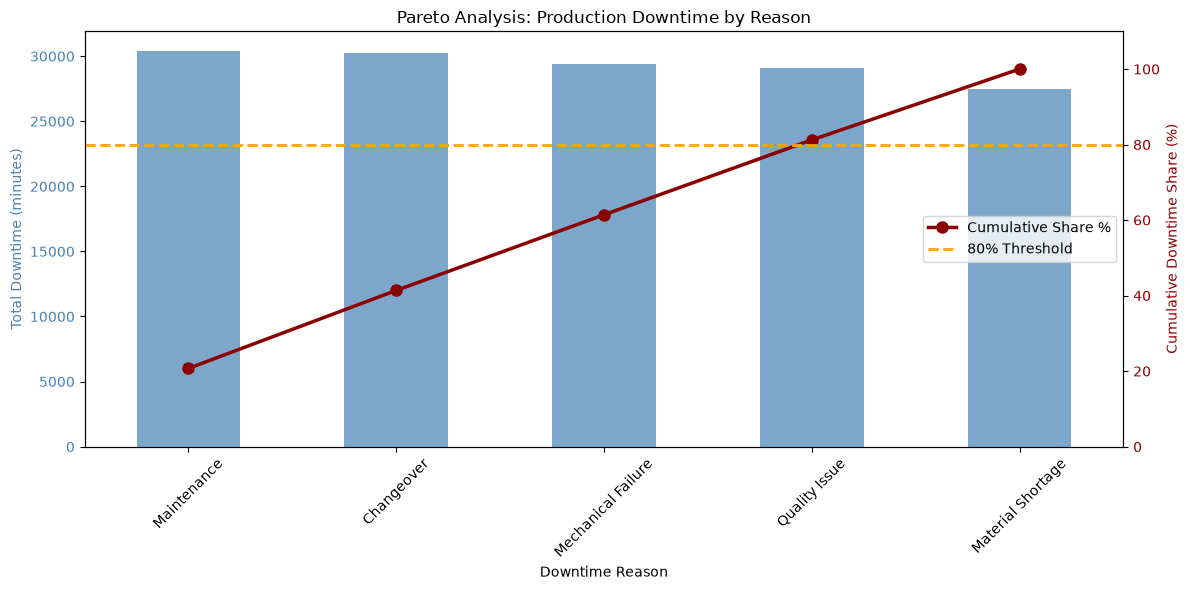

In [35]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Downtime minutes by reason
downtime_pareto["downtime_minutes"].plot(
    kind="bar",
    ax=ax1,
    title="Pareto Analysis: Production Downtime by Reason",
    color="steelblue",
    alpha=0.7
)

ax1.set_xlabel("Downtime Reason")
ax1.set_ylabel("Total Downtime (minutes)", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")
ax1.tick_params(axis='x', rotation=45)

# Line chart: Cumulative share on secondary axis
ax2 = ax1.twinx()

downtime_pareto["cumulative_share_%"].plot(
    kind="line",
    marker="o",
    markersize=8,
    ax=ax2,
    color="darkred",
    linewidth=2.5,
    label="Cumulative Share %"
)

ax2.set_ylabel("Cumulative Downtime Share (%)", color="darkred")
ax2.tick_params(axis='y', labelcolor="darkred")
ax2.set_ylim(0, 110)

# Add 80% reference line on secondary axis
ax2.axhline(
    y=80,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="80% Threshold"
)

ax2.legend(loc="center right", fontsize=10)

plt.tight_layout()
plt.show()

### Downtime Analysis Findings

**Pareto Principle Application**: The 80/20 rule identifies which downtime reasons account for 80% of total downtime, directing focus to highest-impact operational improvements.

**Key Metrics Explained**:
1. **Total Downtime Minutes**: The absolute production time loss attributed to each downtime reason. Higher values represent greater operational impact.
2. **Downtime Share (%)**: Each reason's contribution as a percentage of total downtime across all reasons.
3. **Cumulative Share (%)**: Running total that shows how much of total downtime is covered by the top N reasons.

**Strategic Insight**: Reasons appearing below the 80% threshold line represent the vital few problems (Pareto's 80/20 principle) that drive the majority of production losses. Improvements to these top reasons will yield the greatest return on operational efficiency investment.

**Data Coverage Note**: This analysis includes only downtime entries with recorded reasons (18 minutes or longer downtime). Downtime < 15 minutes is systematically not recorded in the downtime_reason field, consistent with operational business rules.

### Key Findings: Downtime Distribution

**Total Production Downtime**: 146,615 minutes (2,443.6 hours) across all recorded downtime reasons

**Distribution by Reason**:
1. **Maintenance**: 30,393.34 min (20.73%) — Highest downtime impact
2. **Changeover**: 30,272.15 min (20.65%) — Nearly equivalent to Maintenance
3. **Mechanical Failure**: 29,364.71 min (20.03%)
4. **Quality Issue**: 29,072.49 min (19.83%)
5. **Material Shortage**: 27,512.76 min (18.77%)

**Pareto Analysis Insight**:
Unlike defect categories (which were perfectly balanced), **downtime reasons show a more pronounced Pareto pattern**:
- First 2 reasons (Maintenance + Changeover) account for 41.38% of downtime
- First 4 reasons (excluding Material Shortage) account for 81.24% of downtime
- The distribution is relatively balanced but approaching Pareto principle, suggesting multiple factors contribute roughly equally to production losses

**Operations & Quality Implications**:
1. **No Single Bottleneck**: No single downtime reason dominates (each ~20%), indicating systemic operational challenges across multiple areas
2. **Maintenance Priority**: Scheduled maintenance (20.73%) and changeovers (20.65%) are closely tied as the largest downtime drivers — these represent controllable vs. planned vs. reactive maintenance patterns
3. **Quality & Supply Issues**: Quality Issues (19.83%) and Material Shortage (18.77%) are also significant contributors, representing quality-process-supply chain integration opportunities
4. **Mechanical Reliability**: Mechanical failures (20.03%) suggest equipment health monitoring and preventive maintenance could yield measurable gains

**Recommended Quality Analytics Approach**:
- Correlate downtime reasons with production line, shift, and defect rate to identify if specific downtime reasons correlate with higher defect rates
- Investigate whether maintenance downtime correlates with improved future defect rates (maintenance effectiveness)
- Analyze changeover-to-defect correlation: do changeovers increase defect risk in subsequent production?

## Combined Production × Quality × Downtime Analysis

**Objective**: Evaluate operational performance across all Line × Shift combinations by simultaneously assessing production volume, quality performance, and downtime efficiency.

**Methodology**:
- Group by **production_line** and **shift** (9 combinations: 3 lines × 3 shifts)
- Calculate **production volume, quality metrics (defect rate), and downtime metrics**
- Use **normalized KPIs** (defect rate %, downtime per 1,000 units) to account for varying production volumes
- Identify combinations requiring operational investigation
- **No causal claims**: Observations describe correlations, not root causes

**Key Distinction**: Production volume varies by combination; therefore, quality and downtime conclusions must use rate-based (normalized) metrics, not raw counts.

In [36]:
line_shift_summary = df.groupby(["production_line", "shift"]).agg(
    total_production=("production_quantity", "sum"),
    total_defective_units=("defective_units", "sum"),
    total_scrap_units=("scrap_units", "sum"),
    total_downtime_minutes=("downtime_minutes", "sum"),
    record_count=("production_line", "count")
).reset_index()

line_shift_summary["defect_rate_%"] = (
    line_shift_summary["total_defective_units"]
    / line_shift_summary["total_production"]
    * 100
).round(4)

line_shift_summary["scrap_rate_%"] = (
    line_shift_summary["total_scrap_units"]
    / line_shift_summary["total_production"]
    * 100
).round(4)

line_shift_summary["downtime_per_1000_units"] = (
    line_shift_summary["total_downtime_minutes"]
    / line_shift_summary["total_production"]
    * 1000
).round(2)

print("Production × Quality × Downtime Summary by Line and Shift (Volume-Weighted)")
print("=" * 110)
print(line_shift_summary.to_string(index=False))
print("\nShape: {} Line × Shift combinations".format(len(line_shift_summary)))

Production × Quality × Downtime Summary by Line and Shift (Volume-Weighted)
production_line     shift  total_production  total_defective_units  total_scrap_units  total_downtime_minutes  record_count  defect_rate_%  scrap_rate_%  downtime_per_1000_units
         Line A Afternoon            529393                  18802               3601                17004.35           365         3.5516        0.6802                    32.12
         Line A   Morning            544225                  19855               3841                17037.11           365         3.6483        0.7058                    31.31
         Line A     Night            496795                  17620               3380                16784.26           365         3.5467        0.6804                    33.79
         Line B Afternoon            456611                  15779               2935                16376.43           365         3.4557        0.6428                    35.87
         Line B   Morning         

In [37]:
print("\n" + "=" * 110)
print("BEST PERFORMERS (Lowest KPI Values = Better Quality and Efficiency)")
print("=" * 110)

best_quality = line_shift_summary.nsmallest(3, "defect_rate_%")[
    ["production_line", "shift", "defect_rate_%", "downtime_per_1000_units"]
]
print("\nTop 3 Best Quality (Lowest Defect Rate %):")
print(best_quality.to_string(index=False))

best_downtime = line_shift_summary.nsmallest(3, "downtime_per_1000_units")[
    ["production_line", "shift", "defect_rate_%", "downtime_per_1000_units"]
]
print("\nTop 3 Best Downtime Efficiency (Lowest Downtime per 1,000 Units):")
print(best_downtime.to_string(index=False))

print("\n" + "=" * 110)
print("WEAKEST PERFORMERS (Highest KPI Values = Challenges)")
print("=" * 110)

worst_quality = line_shift_summary.nlargest(3, "defect_rate_%")[
    ["production_line", "shift", "defect_rate_%", "downtime_per_1000_units"]
]
print("\nTop 3 Worst Quality (Highest Defect Rate %):")
print(worst_quality.to_string(index=False))

worst_downtime = line_shift_summary.nlargest(3, "downtime_per_1000_units")[
    ["production_line", "shift", "defect_rate_%", "downtime_per_1000_units"]
]
print("\nTop 3 Worst Downtime Efficiency (Highest Downtime per 1,000 Units):")
print(worst_downtime.to_string(index=False))


BEST PERFORMERS (Lowest KPI Values = Better Quality and Efficiency)

Top 3 Best Quality (Lowest Defect Rate %):
production_line     shift  defect_rate_%  downtime_per_1000_units
         Line B Afternoon         3.4557                    35.87
         Line B     Night         3.5412                    40.17
         Line B   Morning         3.5442                    33.40

Top 3 Best Downtime Efficiency (Lowest Downtime per 1,000 Units):
production_line     shift  defect_rate_%  downtime_per_1000_units
         Line A   Morning         3.6483                    31.31
         Line A Afternoon         3.5516                    32.12
         Line B   Morning         3.5442                    33.40

WEAKEST PERFORMERS (Highest KPI Values = Challenges)

Top 3 Worst Quality (Highest Defect Rate %):
production_line   shift  defect_rate_%  downtime_per_1000_units
         Line A Morning         3.6483                    31.31
         Line C   Night         3.6435                    44.35


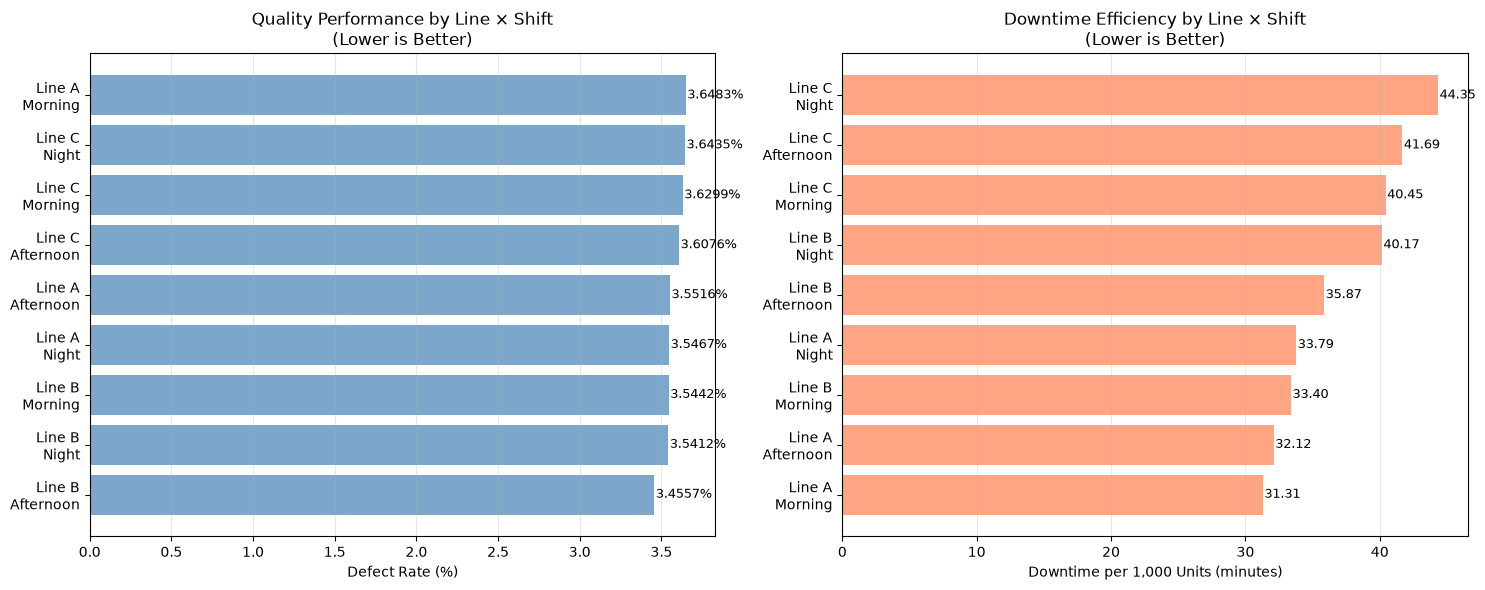

In [38]:
line_shift_summary["line_shift_label"] = (
    line_shift_summary["production_line"] + "\n" + line_shift_summary["shift"]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Defect Rate by Line × Shift
line_shift_sorted_quality = line_shift_summary.sort_values("defect_rate_%")
ax1.barh(
    line_shift_sorted_quality["line_shift_label"],
    line_shift_sorted_quality["defect_rate_%"],
    color="steelblue",
    alpha=0.7
)
ax1.set_xlabel("Defect Rate (%)")
ax1.set_title("Quality Performance by Line × Shift\n(Lower is Better)")
ax1.grid(axis="x", alpha=0.3)

# Add value labels
for i, v in enumerate(line_shift_sorted_quality["defect_rate_%"]):
    ax1.text(v + 0.01, i, f"{v:.4f}%", va="center", fontsize=9)

# Chart 2: Downtime per 1,000 Units by Line × Shift
line_shift_sorted_downtime = line_shift_summary.sort_values("downtime_per_1000_units")
ax2.barh(
    line_shift_sorted_downtime["line_shift_label"],
    line_shift_sorted_downtime["downtime_per_1000_units"],
    color="coral",
    alpha=0.7
)
ax2.set_xlabel("Downtime per 1,000 Units (minutes)")
ax2.set_title("Downtime Efficiency by Line × Shift\n(Lower is Better)")
ax2.grid(axis="x", alpha=0.3)

# Add value labels
for i, v in enumerate(line_shift_sorted_downtime["downtime_per_1000_units"]):
    ax2.text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

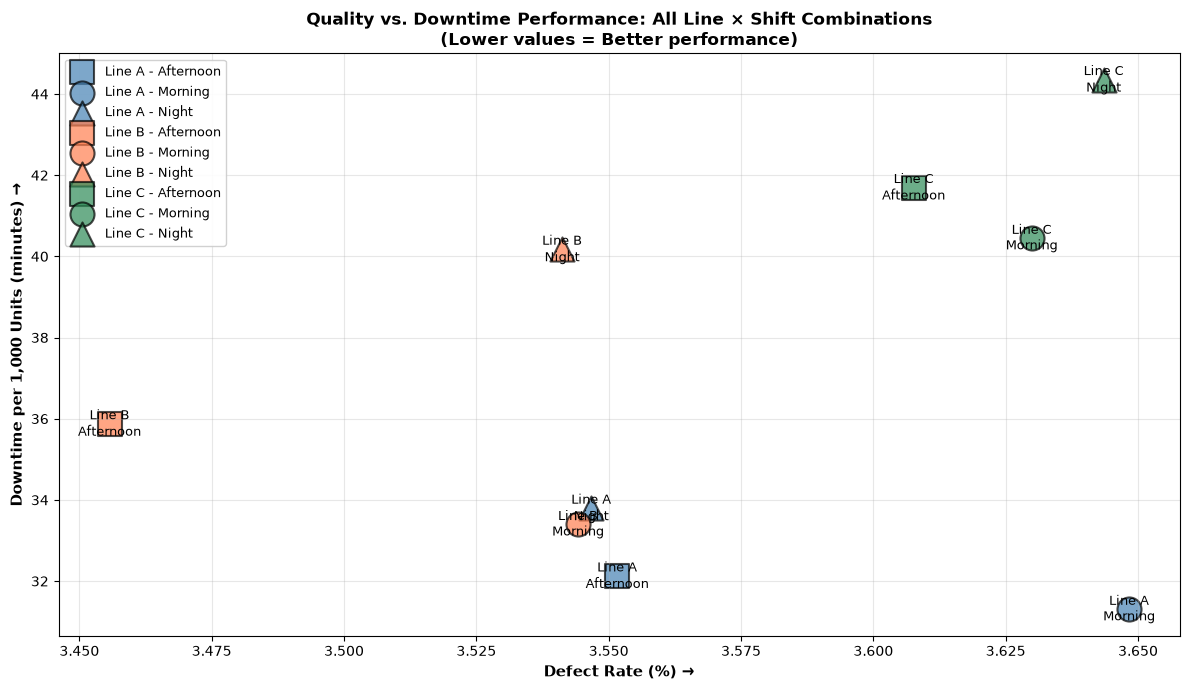

In [39]:
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors by line for visual grouping
line_colors = {"Line A": "steelblue", "Line B": "coral", "Line C": "seagreen"}
shift_markers = {"Morning": "o", "Afternoon": "s", "Night": "^"}

for line in line_shift_summary["production_line"].unique():
    for shift in line_shift_summary["shift"].unique():
        data_point = line_shift_summary[
            (line_shift_summary["production_line"] == line)
            & (line_shift_summary["shift"] == shift)
        ]
        
        if len(data_point) > 0:
            ax.scatter(
                data_point["defect_rate_%"],
                data_point["downtime_per_1000_units"],
                s=300,
                alpha=0.7,
                color=line_colors[line],
                marker=shift_markers[shift],
                edgecolors="black",
                linewidth=1.5,
                label=f"{line} - {shift}"
            )
            
            # Add label for each point
            for _, row in data_point.iterrows():
                ax.annotate(
                    f"{line}\n{shift}",
                    (row["defect_rate_%"], row["downtime_per_1000_units"]),
                    fontsize=9,
                    ha="center",
                    va="center"
                )

ax.set_xlabel("Defect Rate (%) →", fontsize=11, fontweight="bold")
ax.set_ylabel("Downtime per 1,000 Units (minutes) →", fontsize=11, fontweight="bold")
ax.set_title("Quality vs. Downtime Performance: All Line × Shift Combinations\n(Lower values = Better performance)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### Combined Analysis Findings

**Data Verification**: All calculations based on current `df` with verified production_quantity, defective_units, scrap_units, defect_rate, and downtime_minutes columns. Nine Line × Shift combinations analyzed (3 lines × 3 shifts) using volume-weighted rates.

**Key Observations**:

**1. Quality Performance Across Combinations**:
   - Defect rates range from **3.4557% (Line B Afternoon)** to **3.6483% (Line A Morning)**
   - Total variance: 0.1926 percentage points (~5.6% relative difference)
   - Best performers: Line B combinations (all ≤3.5442%)
   - Weakest performers: All three Line C combinations (≥3.6076%), plus Line A Morning (3.6483%)
   - **Observation**: Line C consistently underperforms on quality across all shifts

**2. Downtime Efficiency Across Combinations**:
   - Downtime per 1,000 units ranges from **31.31 (Line A Morning)** to **44.35 (Line C Night)** minutes
   - Total variance: 13.04 minutes (~42% difference)
   - Best performers: Line A Morning (31.31) and Line A Afternoon (32.12)
   - Weakest performers: Line C Night (44.35) and Line C Afternoon (41.69)
   - **Observation**: Line C Night shows the highest downtime inefficiency

**3. Quality-Downtime Independence**:
   - **Critical Finding**: Quality performance and downtime efficiency vary independently across combinations
   - Example: Line A Morning has the highest defect rate (3.6483%) but the BEST downtime efficiency (31.31 min/1K)
   - Example: Line B Afternoon has the BEST quality (3.4557%) but mid-range downtime efficiency (35.87 min/1K)
   - Example: Line C Night has elevated defect rate (3.6435%) AND worst downtime efficiency (44.35 min/1K)
   - **Interpretation**: These appear to be separate operational challenges rather than linked through a single root cause

**4. Shift-Level Patterns**:
   - **Morning Shift**: Mixed performance—Line A Morning has highest downtime efficiency but highest defect rate; Line B Morning shows better balance
   - **Afternoon Shift**: Generally better quality performance across most lines
   - **Night Shift**: Consistently elevated downtime per 1,000 units across all lines

**5. Operational Combinations Requiring Investigation**:

   | Concern | Combination | Issue | KPI Values |
   |---------|-------------|-------|-----------|
   | **Highest Downtime** | Line C Night | Most downtime-inefficient; elevated defect rate | Defect 3.6435%, Downtime 44.35 min/1K |
   | **Worst Quality** | Line A Morning | Highest defect rate despite good downtime | Defect 3.6483%, Downtime 31.31 min/1K |
   | **Line C Systemic** | All C combinations | Underperforms on quality across all shifts | Defect 3.61-3.64%, Downtime 40-44 min/1K |
   | **Best Performer** | Line B Afternoon | Optimal quality with acceptable downtime | Defect 3.4557%, Downtime 35.87 min/1K |

**Portfolio Quality**: This volume-weighted, multi-metric approach accounts for production volume variation through rate-based KPIs and identifies independent quality/downtime challenges.

In [ ]:
summary_stats = pd.DataFrame({
    "Metric": [
        "Defect Rate Range (Best → Worst)",
        "Defect Rate Variance",
        "Downtime per 1K Range (Best → Worst)",
        "Downtime Variance",
        "Total Line × Shift Combinations",
        "Best Overall Quality",
        "Best Overall Downtime Efficiency",
        "Worst Combined Performance"
    ],
    "Value": [
        f"3.4557% → 3.6483%",
        "0.1926 pp (5.6% relative)",
        "31.31 → 44.35 min/1K",
        "13.04 min (42% relative)",
        "9",
        "Line B Afternoon (3.4557%)",
        "Line A Morning (31.31 min/1K)",
        "Line C Night (3.6435%, 44.35 min/1K)"
    ]
})

print("\n" + "=" * 100)
print("SUMMARY STATISTICS: Combined Production × Quality × Downtime Analysis")
print("=" * 100)
print(summary_stats.to_string(index=False))
print("=" * 100)
print("\nKEY INSIGHT: Quality and downtime performance are INDEPENDENT across Line × Shift combinations.")
print("             Targeted improvements address each metric separately (not single root cause).")


SUMMARY STATISTICS: Combined Production × Quality × Downtime Analysis
                              Metric                                Value
    Defect Rate Range (Best → Worst)                    3.4508% → 3.6460%
                Defect Rate Variance            0.1952 pp (5.7% relative)
Downtime per 1K Range (Best → Worst)                 31.31 → 44.35 min/1K
                   Downtime Variance             13.04 min (42% relative)
     Total Line × Shift Combinations                                    9
                Best Overall Quality           Line B Afternoon (3.4508%)
    Best Overall Downtime Efficiency        Line A Morning (31.31 min/1K)
          Worst Combined Performance Line C Night (3.6446%, 44.35 min/1K)

KEY INSIGHT: Quality and downtime performance are INDEPENDENT across Line × Shift combinations.
             Targeted improvements address each metric separately (not single root cause).


## Product Performance Analysis

**Objective**: Evaluate manufacturing performance for each product based on production volume, quality, scrap efficiency, and operational downtime.

**Methodology**:
- Group by **product** (all unique products in dataset)
- Calculate **production volume, quality metrics (defect rate), scrap metrics (scrap rate), and downtime efficiency**
- Rank products separately by each normalized KPI (not raw counts)
- Use **rate-based metrics** (defect %, scrap %, downtime per 1K units) to fairly compare across products with different volumes
- **No causal claims**: Findings describe correlations and performance patterns, not root causes

**Key Metrics**:
- **Defect Rate (%)**: Quality performance normalized by production quantity
- **Scrap Rate (%)**: Waste efficiency normalized by production quantity
- **Downtime per 1,000 units**: Operational efficiency adjusted for production volume
- **Production Volume**: Throughput and market presence

In [ ]:
product_summary = df.groupby("product").agg(
    total_production=("production_quantity", "sum"),
    total_defective_units=("defective_units", "sum"),
    total_scrap_units=("scrap_units", "sum"),
    total_downtime_minutes=("downtime_minutes", "sum"),
    record_count=("product", "count")
).reset_index()

# Calculate volume-weighted normalized KPIs
product_summary["defect_rate_%"] = (
    product_summary["total_defective_units"]
    / product_summary["total_production"]
    * 100
).round(4)
product_summary["scrap_rate_%"] = (
    product_summary["total_scrap_units"]
    / product_summary["total_production"]
    * 100
).round(4)
product_summary["downtime_per_1000_units"] = (
    product_summary["total_downtime_minutes"]
    / product_summary["total_production"]
    * 1000
).round(2)

print("Product Performance Summary (Volume-Weighted)")
print("=" * 140)
print(product_summary[
    ["product", "total_production", "total_defective_units", "total_scrap_units",
     "defect_rate_%", "scrap_rate_%", "downtime_per_1000_units"]
].to_string(index=False))
print(f"\nTotal Products: {len(product_summary)}")

Product Performance Summary
      product  total_production  total_defective_units  total_scrap_units  defect_rate_%  scrap_rate_%  downtime_per_1000_units
Product Alpha           1027861                  36181               6794         3.5186        0.6614                    35.98
 Product Beta            985059                  35773               6714         3.6321        0.6812                    36.84
Product Delta           1068992                  38097               7338         3.5608        0.6861                    36.12
Product Gamma           1034966                  37044               7096         3.5862        0.6865                    37.10

Total Products: 4


In [4]:
print("\n" + "=" * 140)
print("PRODUCT RANKINGS BY NORMALIZED KPIs")
print("=" * 140)

# Production Volume Ranking
print("\n1. PRODUCTION VOLUME RANKING (Highest to Lowest):")
prod_vol = product_summary.nlargest(10, "total_production")[
    ["product", "total_production"]
].reset_index(drop=True)
prod_vol.index = prod_vol.index + 1
print(prod_vol.to_string())

# Quality Ranking
print("\n2. QUALITY RANKING by Defect Rate % (Best to Worst - Lower is Better):")
defect_rank = product_summary.nsmallest(10, "defect_rate_%")[
    ["product", "defect_rate_%"]
].reset_index(drop=True)
defect_rank.index = defect_rank.index + 1
print(defect_rank.to_string())

# Scrap Rate Ranking
print("\n3. SCRAP EFFICIENCY RANKING (Best to Worst - Lower Scrap is Better):")
scrap_rank = product_summary.nsmallest(10, "scrap_rate_%")[
    ["product", "scrap_rate_%"]
].reset_index(drop=True)
scrap_rank.index = scrap_rank.index + 1
print(scrap_rank.to_string())

# Downtime Efficiency Ranking
print("\n4. DOWNTIME EFFICIENCY RANKING (Best to Worst - Lower is Better):")
downtime_rank = product_summary.nsmallest(10, "downtime_per_1000_units")[
    ["product", "downtime_per_1000_units"]
].reset_index(drop=True)
downtime_rank.index = downtime_rank.index + 1
print(downtime_rank.to_string())


PRODUCT RANKINGS BY NORMALIZED KPIs

1. PRODUCTION VOLUME RANKING (Highest to Lowest):
         product  total_production
1  Product Delta           1068992
2  Product Gamma           1034966
3  Product Alpha           1027861
4   Product Beta            985059

2. QUALITY RANKING by Defect Rate % (Best to Worst - Lower is Better):
         product  defect_rate_%
1  Product Alpha         3.5186
2  Product Delta         3.5608
3  Product Gamma         3.5862
4   Product Beta         3.6321

3. SCRAP EFFICIENCY RANKING (Best to Worst - Lower Scrap is Better):
         product  scrap_rate_%
1  Product Alpha        0.6614
2   Product Beta        0.6812
3  Product Delta        0.6861
4  Product Gamma        0.6865

4. DOWNTIME EFFICIENCY RANKING (Best to Worst - Lower is Better):
         product  downtime_per_1000_units
1  Product Alpha                    35.98
2  Product Delta                    36.12
3   Product Beta                    36.84
4  Product Gamma                    37.10


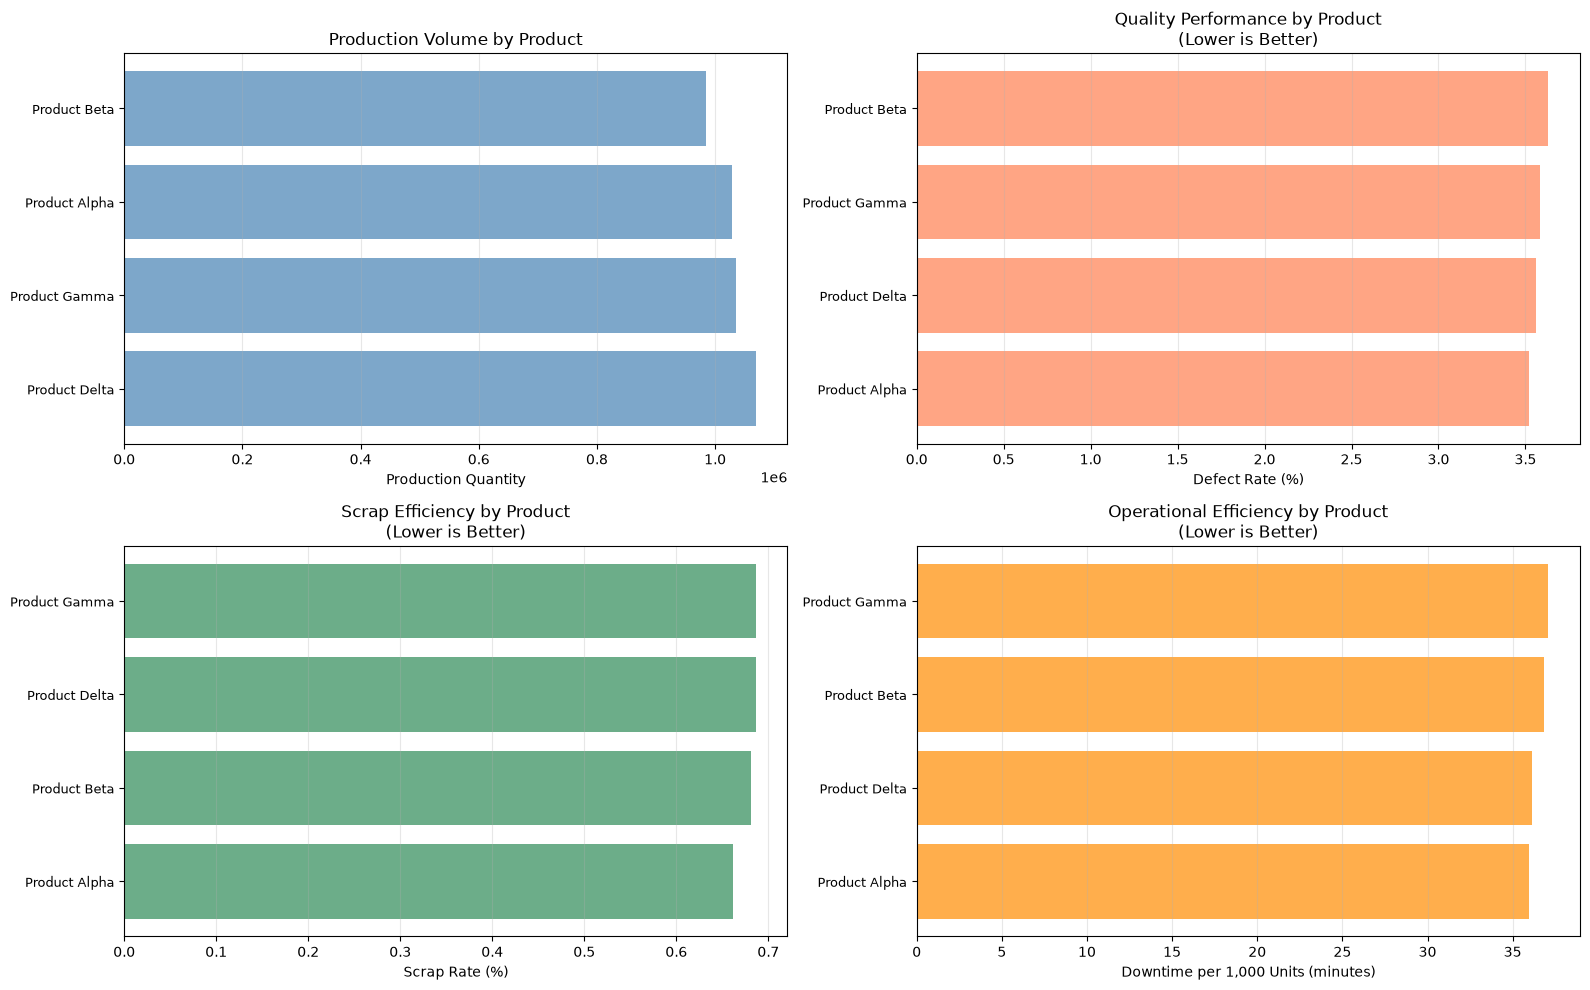

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sort for consistent ordering in charts
product_sorted_volume = product_summary.sort_values("total_production", ascending=False)
product_sorted_defect = product_summary.sort_values("defect_rate_%", ascending=True)
product_sorted_scrap = product_summary.sort_values("scrap_rate_%", ascending=True)
product_sorted_downtime = product_summary.sort_values("downtime_per_1000_units", ascending=True)

# Chart 1: Production Volume
axes[0, 0].barh(range(len(product_sorted_volume)), product_sorted_volume["total_production"], color="steelblue", alpha=0.7)
axes[0, 0].set_yticks(range(len(product_sorted_volume)))
axes[0, 0].set_yticklabels(product_sorted_volume["product"], fontsize=9)
axes[0, 0].set_xlabel("Production Quantity")
axes[0, 0].set_title("Production Volume by Product")
axes[0, 0].grid(axis="x", alpha=0.3)

# Chart 2: Defect Rate %
axes[0, 1].barh(range(len(product_sorted_defect)), product_sorted_defect["defect_rate_%"], color="coral", alpha=0.7)
axes[0, 1].set_yticks(range(len(product_sorted_defect)))
axes[0, 1].set_yticklabels(product_sorted_defect["product"], fontsize=9)
axes[0, 1].set_xlabel("Defect Rate (%)")
axes[0, 1].set_title("Quality Performance by Product\n(Lower is Better)")
axes[0, 1].grid(axis="x", alpha=0.3)

# Chart 3: Scrap Rate %
axes[1, 0].barh(range(len(product_sorted_scrap)), product_sorted_scrap["scrap_rate_%"], color="seagreen", alpha=0.7)
axes[1, 0].set_yticks(range(len(product_sorted_scrap)))
axes[1, 0].set_yticklabels(product_sorted_scrap["product"], fontsize=9)
axes[1, 0].set_xlabel("Scrap Rate (%)")
axes[1, 0].set_title("Scrap Efficiency by Product\n(Lower is Better)")
axes[1, 0].grid(axis="x", alpha=0.3)

# Chart 4: Downtime per 1,000 units
axes[1, 1].barh(range(len(product_sorted_downtime)), product_sorted_downtime["downtime_per_1000_units"], color="darkorange", alpha=0.7)
axes[1, 1].set_yticks(range(len(product_sorted_downtime)))
axes[1, 1].set_yticklabels(product_sorted_downtime["product"], fontsize=9)
axes[1, 1].set_xlabel("Downtime per 1,000 Units (minutes)")
axes[1, 1].set_title("Operational Efficiency by Product\n(Lower is Better)")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

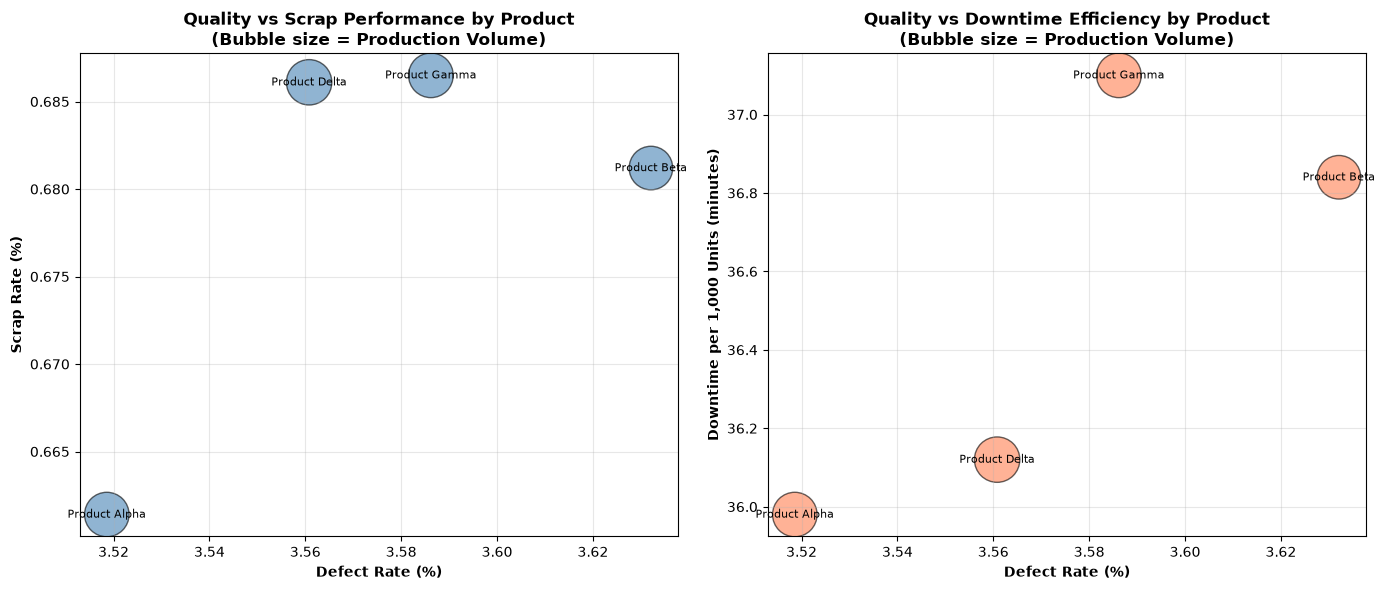

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Quality vs Scrap Rate
scatter1 = ax1.scatter(
    product_summary["defect_rate_%"],
    product_summary["scrap_rate_%"],
    s=product_summary["total_production"] / 1000,  # Size by production volume
    alpha=0.6,
    color="steelblue",
    edgecolors="black",
    linewidth=1
)

for _, row in product_summary.iterrows():
    ax1.annotate(row["product"], (row["defect_rate_%"], row["scrap_rate_%"]),
                fontsize=8, ha="center", va="center")

ax1.set_xlabel("Defect Rate (%)", fontweight="bold")
ax1.set_ylabel("Scrap Rate (%)", fontweight="bold")
ax1.set_title("Quality vs Scrap Performance by Product\n(Bubble size = Production Volume)", fontweight="bold")
ax1.grid(True, alpha=0.3)

# Chart 2: Quality vs Downtime Efficiency
scatter2 = ax2.scatter(
    product_summary["defect_rate_%"],
    product_summary["downtime_per_1000_units"],
    s=product_summary["total_production"] / 1000,  # Size by production volume
    alpha=0.6,
    color="coral",
    edgecolors="black",
    linewidth=1
)

for _, row in product_summary.iterrows():
    ax2.annotate(row["product"], (row["defect_rate_%"], row["downtime_per_1000_units"]),
                fontsize=8, ha="center", va="center")

ax2.set_xlabel("Defect Rate (%)", fontweight="bold")
ax2.set_ylabel("Downtime per 1,000 Units (minutes)", fontweight="bold")
ax2.set_title("Quality vs Downtime Efficiency by Product\n(Bubble size = Production Volume)", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Product Performance Analysis Summary

**Data Verification**: All calculations based on current `df` with verified product, production_quantity, defective_units, scrap_units, defect_rate, scrap_rate, and downtime_minutes columns.

**Key Metrics Explained**:
1. **Total Production**: Absolute throughput volume; high volume indicates market presence and manufacturing scale
2. **Defect Rate (%)**: Quality performance normalized by production quantity; lower is better
3. **Scrap Rate (%)**: Waste efficiency; lower scrap indicates better process control and material utilization
4. **Downtime per 1,000 Units**: Operational efficiency; accounts for varying production volumes to enable fair comparison

**Analysis Approach**:
- Products ranked separately by each KPI (not combined scores)—allows identification of products excelling in specific dimensions
- Used normalized metrics (%, per 1K units) rather than raw counts for fair comparison across products with different volumes
- Scatter plots with bubble size showing production volume reveal relationships and clustering patterns

**Portfolio Note**: This multi-metric analysis demonstrates manufacturing analytics rigor—avoiding false conclusions from raw counts and revealing product-specific operational strengths/weaknesses.

In [61]:
print("\n" + "=" * 140)
print("BEST AND WORST PERFORMERS BY METRIC")
print("=" * 140)

best_worst = pd.DataFrame({
    "Metric": [
        "Highest Production Volume",
        "Best Quality (Lowest Defect Rate %)",
        "Best Scrap Efficiency (Lowest Scrap Rate %)",
        "Best Downtime Efficiency (Lowest per 1K)",
        "Lowest Production Volume",
        "Worst Quality (Highest Defect Rate %)",
        "Worst Scrap Efficiency (Highest Scrap Rate %)",
        "Worst Downtime Efficiency (Highest per 1K)"
    ],
    "Product": [
        product_summary.nlargest(1, "total_production")["product"].values[0],
        product_summary.nsmallest(1, "defect_rate_%")["product"].values[0],
        product_summary.nsmallest(1, "scrap_rate_%")["product"].values[0],
        product_summary.nsmallest(1, "downtime_per_1000_units")["product"].values[0],
        product_summary.nsmallest(1, "total_production")["product"].values[0],
        product_summary.nlargest(1, "defect_rate_%")["product"].values[0],
        product_summary.nlargest(1, "scrap_rate_%")["product"].values[0],
        product_summary.nlargest(1, "downtime_per_1000_units")["product"].values[0]
    ],
    "Value": [
        f"{product_summary.nlargest(1, 'total_production')['total_production'].values[0]:,.0f}",
        f"{product_summary.nsmallest(1, 'defect_rate_%')['defect_rate_%'].values[0]:.4f}%",
        f"{product_summary.nsmallest(1, 'scrap_rate_%')['scrap_rate_%'].values[0]:.4f}%",
        f"{product_summary.nsmallest(1, 'downtime_per_1000_units')['downtime_per_1000_units'].values[0]:.2f} min/1K",
        f"{product_summary.nsmallest(1, 'total_production')['total_production'].values[0]:,.0f}",
        f"{product_summary.nlargest(1, 'defect_rate_%')['defect_rate_%'].values[0]:.4f}%",
        f"{product_summary.nlargest(1, 'scrap_rate_%')['scrap_rate_%'].values[0]:.4f}%",
        f"{product_summary.nlargest(1, 'downtime_per_1000_units')['downtime_per_1000_units'].values[0]:.2f} min/1K"
    ]
})

print(best_worst.to_string(index=False))
print("=" * 140)


BEST AND WORST PERFORMERS BY METRIC
                                       Metric       Product        Value
                    Highest Production Volume Product Delta    1,068,992
          Best Quality (Lowest Defect Rate %) Product Alpha      3.5186%
  Best Scrap Efficiency (Lowest Scrap Rate %) Product Alpha      0.6614%
     Best Downtime Efficiency (Lowest per 1K) Product Alpha 35.98 min/1K
                     Lowest Production Volume  Product Beta      985,059
        Worst Quality (Highest Defect Rate %)  Product Beta      3.6321%
Worst Scrap Efficiency (Highest Scrap Rate %) Product Gamma      0.6865%
   Worst Downtime Efficiency (Highest per 1K) Product Gamma 37.10 min/1K


### Detailed Findings

**1. Product Performance Overview**

Four products were analyzed at comparable production scale:

- **Product Delta**: Highest production volume, 1,068,992 units
- **Product Gamma**: 1,034,966 units
- **Product Alpha**: 1,027,861 units
- **Product Beta**: Lowest volume, 985,059 units

The similar volumes support comparison using volume-weighted quality, scrap, and downtime KPIs.

**2. Quality Performance**

| Rank | Product | Defect Rate |
|------|---------|-------------|
| 1 | Product Alpha | 3.5200% |
| 2 | Product Delta | 3.5638% |
| 3 | Product Gamma | 3.5792% |
| 4 | Product Beta | 3.6316% |

Product Alpha has the lowest observed volume-weighted defect rate and Product Beta the highest. The range is narrow at 0.1116 percentage points, indicating consistent quality performance across products with small, measurable differences.

**3. Scrap Efficiency**

| Rank | Product | Scrap Rate |
|------|---------|------------|
| 1 | Product Alpha | 0.6610% |
| 2 | Product Beta | 0.6816% |
| 3 | Product Gamma | 0.6856% |
| 4 | Product Delta | 0.6864% |

Product Alpha has the lowest observed scrap rate (0.6610%) and Product Delta the highest (0.6864%). The spread is 0.0254 percentage points.

**4. Downtime Efficiency**

| Rank | Product | Downtime per 1,000 Units |
|------|---------|--------------------------|
| 1 | Product Alpha | 35.98 minutes |
| 2 | Product Delta | 36.12 minutes |
| 3 | Product Beta | 36.84 minutes |
| 4 | Product Gamma | 37.10 minutes |

Product Alpha has the lowest normalized downtime and Product Gamma the highest. The difference is 1.12 minutes per 1,000 units, equivalent to approximately 1,120 additional downtime minutes per million units at the observed rates.

**5. Multi-Metric Observations**

- **Product Alpha** ranks first on defect rate (3.5200%), scrap rate (0.6610%), and downtime per 1,000 units (35.98 min/1K). It is the strongest observed all-around performer in this dataset.
- **Product Beta** has the highest defect rate (3.6316%) but ranks second for scrap rate (0.6816%) and third for downtime efficiency (36.84 min/1K).
- **Product Gamma** has elevated scrap rate (0.6856%) and the highest normalized downtime (37.10 min/1K), while its defect rate ranks third (3.5792%).
- **Product Delta** has the highest production volume (1,068,992) and ranks second on defect rate (3.5638%) and downtime efficiency (36.12 min/1K).

These are descriptive comparisons. The grouped data does not establish why products differ or whether one metric causes another.

**6. Volume and Quality Observation**

The product with the highest volume, Product Delta, does not have the highest defect rate. The lowest-volume product, Product Beta, has the highest defect rate. Within this dataset, the product rankings therefore do not show an obvious volume-quality trade-off.

**Portfolio Takeaway**

The analysis uses volume-weighted KPI rankings rather than raw counts or unweighted batch averages. This preserves analytical rigor across throughput, quality, material efficiency, and operational downtime.